In [ ]:
# ===============================================
# BERT（ローカル）の埋め込みで
# ツイート内容の「散らばり度」を半年ごとに可視化する完全コード
#  - モデル: C:/hf_models/bert-japanese-v2
#  - 入力CSV: C:/Users/mzjin/OneDrive/デスクトップ/tweet(original).csv
# ===============================================

import os
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"  # 念のためHFのテレメトリをOFF（なくてもOK）

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt


###############################################
# 0. 設定
###############################################

# 入力CSV（UTF-8）
INPUT_CSV = r"C:\Users\mzjin\OneDrive\デスクトップ\tweet(original).csv"
# 出力CSV
OUTPUT_CSV = "periods_scatter.csv"

# ローカルの日本語BERTモデルディレクトリ
MODEL_DIR = r"C:\hf_models\bert-japanese-v2"

# GPU があれば GPU を使う
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


###############################################
# 1. データ読み込み & 前処理
###############################################

# tweet(original).csv は [0列: 日付文字列, 1列: テキスト] という想定
df = pd.read_csv(INPUT_CSV, header=None, encoding="utf-8")

# 列名を付ける
df.columns = ["datetime", "text"]

# "Jun 29,2022" → "Jun 29, 2022" 的なカンマ周りの空白を整形
df["datetime"] = (
    df["datetime"]
    .astype(str)
    .str.replace(r"\s*,\s*", ",", regex=True)
    .str.strip()
)

# 日付を datetime 型に変換（Jun 29,2022 形式）
df["datetime"] = pd.to_datetime(
    df["datetime"],
    format="%b %d,%Y",   # 例: "Jun 29,2022"
    errors="coerce"      # 変換できないものは NaT
)

print(df.head())
print("NaT 割合:", df["datetime"].isna().mean())

# 日付が読めない行は除外
df = df.dropna(subset=["datetime"]).reset_index(drop=True)

# テキストが欠損なら空文字に
df["text"] = df["text"].fillna("")

# 半年ごとの期間ラベルを作る
def make_halfyear_label(ts):
    year = ts.year
    half = 1 if ts.month <= 6 else 2
    return f"{year}_H{half}"

df["period"] = df["datetime"].apply(make_halfyear_label)

print("期間ごとの件数：")
print(df["period"].value_counts().sort_index())
print()


###############################################
# 2. BERT の準備（ローカルの bert-japanese-v2 を使用）
###############################################

print("ローカルモデル読み込み中...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
model = AutoModel.from_pretrained(MODEL_DIR, local_files_only=True).to(device)
model.eval()
print("モデル読み込み完了")


###############################################
# 3. テキストを BERT ベクトルに変換
###############################################

def encode_texts(texts, batch_size=16, max_length=128):
    """
    texts: pandas.Series もしくは list[str]
    戻り値: numpy.ndarray (N, D)
    """
    all_embs = []

    # バッチ処理
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size].tolist()

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)
            # [CLS] トークンのベクトルを使用
            cls_emb = outputs.last_hidden_state[:, 0, :]  # (B, hidden_size)
            # L2正規化（距離比較しやすくするため）
            cls_emb = torch.nn.functional.normalize(cls_emb, p=2, dim=1)

        all_embs.append(cls_emb.cpu().numpy())

        # ざっくり進捗表示
        if (i // batch_size) % 10 == 0:
            print(f"  encoded {i + len(batch_texts)} / {len(texts)}")

    return np.vstack(all_embs)


print("テキストをエンコード中...")
embeddings = encode_texts(df["text"])
print("エンコード完了: 形状 =", embeddings.shape)  # (N, D)

# データフレームにくっつける（行ごとにベクトルを持たせる）
df["emb"] = list(embeddings)


###############################################
# 4. 半年ごとの「散らばり度」を計算
###############################################

results = []

for period, sub in df.groupby("period"):
    embs = np.vstack(sub["emb"].to_list())  # (n_i, D)

    # 重心（平均ベクトル）
    centroid = embs.mean(axis=0, keepdims=True)

    # 各ツイートとのユークリッド距離
    dists = np.linalg.norm(embs - centroid, axis=1)

    # 指標：平均距離と分散（どちらも「広がり」の指標）
    mean_dist = float(dists.mean())
    var_dist = float(dists.var())

    results.append({
        "period": period,
        "n_tweets": len(sub),
        "mean_distance": mean_dist,
        "var_distance": var_dist
    })

# 結果をまとめてソート
res_df = pd.DataFrame(results).sort_values("period").reset_index(drop=True)
print("\n==== 半年ごとの散らばり度 ====")
print(res_df)

# CSV に保存
res_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"\n結果を {OUTPUT_CSV} に保存しました。")


###############################################
# 5. グラフ表示（散らばり度・平均距離）
###############################################

# ===== 1. データ読み込み（念のためCSVから） =====
df_plot = pd.read_csv(OUTPUT_CSV)

# period を時系列順に並べ替え（既にソート済みだが保険として）
df_plot = df_plot.sort_values("period").reset_index(drop=True)
print(df_plot)

# ===== 2. 散らばり度（分散）のグラフ =====
plt.figure(figsize=(8, 4))

plt.plot(df_plot["period"], df_plot["var_distance"], marker="o")
plt.xlabel("期間（半年ごと）", fontsize=12)
plt.ylabel("散らばり度（var_distance）", fontsize=12)
plt.title("半年ごとのツイート内容の散らばり（BERTベクトル）", fontsize=14)

# 各点の上にツイート数を小さく表示
for i, row in df_plot.iterrows():
    plt.text(
        row["period"],
        row["var_distance"],
        f'n={row["n_tweets"]}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ===== 3. 「平均距離」のグラフ =====
plt.figure(figsize=(8, 4))

plt.plot(df_plot["period"], df_plot["mean_distance"], marker="o")
plt.xlabel("期間（半年ごと）", fontsize=12)
plt.ylabel("平均距離（mean_distance）", fontsize=12)
plt.title("半年ごとの中心テーマからのズレ（平均距離）", fontsize=14)

for i, row in df_plot.iterrows():
    plt.text(
        row["period"],
        row["mean_distance"],
        f'n={row["n_tweets"]}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [10]:
# ===============================================
# BERT埋め込み + PCA でツイートの意味空間を可視化する完全スクリプト
#
# - ローカルBERTモデル: C:/hf_models/bert-japanese-v2
# - 入力CSV         : C:/Users/mzjin/OneDrive/デスクトップ/tweet(original).csv
# - 出力           : PCA 2次元散布図（半年ごとに色分け + 重心の軌跡）
# ===============================================

import os
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"  # 念のためHFのテレメトリをOFF（なくてもOK）

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# -----------------------------------------------
# 0. 設定
# -----------------------------------------------
INPUT_CSV = r"C:\Users\mzjin\OneDrive\デスクトップ\tweet(original).csv"
MODEL_DIR = r"C:\hf_models\bert-japanese-v2"

# GPU があれば GPU を使う
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


# -----------------------------------------------
# 1. データ読み込み & 前処理
# -----------------------------------------------
def load_and_prepare_data(csv_path: str) -> pd.DataFrame:
    """
    tweet(original).csv を読み込み、
    - datetime列を datetime 型に変換
    - text の欠損を空文字に
    - 半年ごとの period ラベルを追加
    を行った DataFrame を返す。
    """
    # CSV 読み込み（[0列: 日付文字列, 1列: テキスト] 前提）
    df = pd.read_csv(csv_path, header=None, encoding="utf-8")
    df.columns = ["datetime", "text"]

    # "Jun 29,2022" → "Jun 29, 2022" 的なカンマ周りの空白を整形
    df["datetime"] = (
        df["datetime"]
        .astype(str)
        .str.replace(r"\s*,\s*", ",", regex=True)
        .str.strip()
    )

    # 日付文字列を datetime 型に変換（例: "Jun 29,2022"）
    df["datetime"] = pd.to_datetime(
        df["datetime"],
        format="%b %d,%Y",
        errors="coerce",  # 変換できないものは NaT
    )

    print("先頭5行:")
    print(df.head())
    print("NaT 割合:", df["datetime"].isna().mean())

    # 日付が読めない行は除外
    df = df.dropna(subset=["datetime"]).reset_index(drop=True)

    # テキストが欠損なら空文字に
    df["text"] = df["text"].fillna("")

    # 半年ごとの期間ラベルを作る
    def make_halfyear_label(ts):
        year = ts.year
        half = 1 if ts.month <= 6 else 2
        return f"{year}_H{half}"

    df["period"] = df["datetime"].apply(make_halfyear_label)

    print("期間ごとの件数：")
    print(df["period"].value_counts().sort_index())
    print()

    return df


# -----------------------------------------------
# 2. BERT モデルの読み込み（ローカル）
# -----------------------------------------------
def load_bert_model(model_dir: str):
    """
    ローカルディレクトリから日本語 BERT モデルとトークナイザを読み込む。
    """
    print("ローカルモデル読み込み中...")
    tokenizer = AutoTokenizer.from_pretrained(model_dir, local_files_only=True)
    model = AutoModel.from_pretrained(model_dir, local_files_only=True).to(device)
    model.eval()
    print("モデル読み込み完了")
    return tokenizer, model


# -----------------------------------------------
# 3. テキストを BERT ベクトルに変換
# -----------------------------------------------
def encode_texts(texts, tokenizer, model, batch_size=16, max_length=128):
    """
    texts: pandas.Series または list[str]
    戻り値: numpy.ndarray (N, D)
    """
    all_embs = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size].tolist()

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)
            # [CLS] トークンのベクトルを使用
            cls_emb = outputs.last_hidden_state[:, 0, :]  # (B, hidden_size)
            # L2 正規化（ベクトルの長さを1に揃える）
            cls_emb = torch.nn.functional.normalize(cls_emb, p=2, dim=1)

        all_embs.append(cls_emb.cpu().numpy())

        # ざっくり進捗表示
        if (i // batch_size) % 10 == 0:
            print(f"  encoded {i + len(batch_texts)} / {len(texts)}")

    return np.vstack(all_embs)


# -----------------------------------------------
# 4. PCA で 2 次元に圧縮
# -----------------------------------------------
def run_pca(embeddings: np.ndarray, n_components: int = 2):
    """
    埋め込みベクトル (N, D) に PCA を適用して、
    (N, n_components) の主成分スコアと PCA モデルを返す。
    """
    print("PCA 実行中...")
    pca = PCA(n_components=n_components, random_state=0)
    X_2d = pca.fit_transform(embeddings)
    print("PCA 完了。分散説明率:", pca.explained_variance_ratio_)
    return X_2d, pca


# -----------------------------------------------
# 5. period を時間順に並べるユーティリティ
# -----------------------------------------------
def period_to_order(p: str) -> int:
    """
    "2020_H1" -> 2020*2 + (1-1) = 4040
    "2020_H2" -> 2020*2 + (2-1) = 4041
    のように、時間順を一意に表す整数に変換する。
    """
    year_str, half_str = p.split("_H")
    year = int(year_str)
    half = int(half_str)
    return year * 2 + (half - 1)


# -----------------------------------------------
# 6. 散布図の描画
# -----------------------------------------------
def plot_pca_scatter(df: pd.DataFrame):
    """
    df: 以下の列を持つ DataFrame
        - pc1, pc2: PCAで2次元に圧縮した座標
        - period: 半年ごとのラベル (例: "2020_H1")
    """

    # 時系列順にユニークな period を並べる
    unique_periods = sorted(df["period"].unique(), key=period_to_order)

    # カラーマップ（古いperiod→新しいperiodへグラデーション）
    cmap = plt.cm.get_cmap("viridis", len(unique_periods))

    # ---- 6-1. ツイート散布図（点を半年ごとに色分け） ----
    plt.figure(figsize=(8, 6))

    for idx, period in enumerate(unique_periods):
        mask = df["period"] == period
        plt.scatter(
            df.loc[mask, "pc1"],
            df.loc[mask, "pc2"],
            s=20,
            alpha=0.6,
            color=cmap(idx),
            label=period,
        )

    plt.xlabel("PC1", fontsize=12)
    plt.ylabel("PC2", fontsize=12)
    plt.title("BERT埋め込みのPCA散布図（色: 半年ごと）", fontsize=14)
    plt.legend(
        title="period（古い→新しい）",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

    # ---- 6-2. 半年ごとの「重心」を線で結んで時系列を強調 ----
    centroids = (
        df.groupby("period")[["pc1", "pc2"]]
        .mean()
        .loc[unique_periods]  # 時系列順に並べ替え
        .reset_index()
    )

    plt.figure(figsize=(8, 6))

    # 背景に全ツイートを薄く表示
    plt.scatter(
        df["pc1"], df["pc2"],
        s=10,
        alpha=0.2,
        color="gray",
        label="tweets",
    )

    # 重心を線で結ぶ（時系列の軌跡）
    plt.plot(
        centroids["pc1"],
        centroids["pc2"],
        marker="o",
        linestyle="-",
    )

    # 各重心に period ラベルを表示
    for _, row in centroids.iterrows():
        plt.text(
            row["pc1"],
            row["pc2"],
            row["period"],
            fontsize=9,
            ha="center",
            va="bottom",
        )

    plt.xlabel("PC1", fontsize=12)
    plt.ylabel("PC2", fontsize=12)
    plt.title("半年ごとの意味空間での軌跡（PCA 2次元）", fontsize=14)
    plt.tight_layout()
    plt.show()


# -----------------------------------------------
# メイン処理
# -----------------------------------------------
def main():
    # 1. データ読み込み
    df = load_and_prepare_data(INPUT_CSV)

    # 2. BERTモデル読み込み
    tokenizer, model = load_bert_model(MODEL_DIR)

    # 3. テキストを BERT 埋め込みに変換
    print("テキストをエンコード中...")
    embeddings = encode_texts(df["text"], tokenizer, model)
    print("エンコード完了: 形状 =", embeddings.shape)  # (N, D)

    # 4. PCAで2次元に圧縮
    X_2d, pca = run_pca(embeddings, n_components=2)

    # 5. 主成分スコアを df に追加
    df["pc1"] = X_2d[:, 0]
    df["pc2"] = X_2d[:, 1]

       # ---- 6-1. ツイート散布図（点を半年ごとに色分け） ----
    plt.figure(figsize=(8, 6))

    # 古い matplotlib でも動くカラーマップ
    cmap = plt.cm.viridis  

    for idx, period in enumerate(unique_periods):
        mask = df["period"] == period

        # 均等に色を割り当てる（0〜1の範囲）
        color = cmap(idx / max(len(unique_periods) - 1, 1))

        plt.scatter(
            df.loc[mask, "pc1"],
            df.loc[mask, "pc2"],
            s=20,
            alpha=0.6,
            color=color,
            label=period,
        )


device: cpu


device: cpu
先頭5行:
    datetime                                               text
0 2022-06-29  ロシアが核を撃てばNATOが何カ国増えようが何も変わらない。ルールを守るのはそのルールを守る...
1 2022-06-29  ＜自民党憲法草案第十一条 国民は、全ての基本的人権を享有する。 この憲法が国民に保障する基本...
2 2022-06-29  自民党憲法草案第十一条 国民は、全ての基本的人権を享有する。 この憲法が国民に保障する基本的...
3 2022-06-26  「これ迄の彼は死んだ。今有るのは、厭世を湛えた路傍の石ころのような存在。石は動かない、奥底の...
4 2022-06-26  A.N.さん (これ迄の彼は死んだ。今有るのは、厭世を湛えた路傍の石ころのような存在。石は動...
NaT 割合: 0.020100502512562814
期間ごとの件数：
period
2019_H2    187
2020_H1    179
2020_H2    340
2021_H1    198
2021_H2     26
2022_H1     45
Name: count, dtype: int64

ローカルモデル読み込み中...
モデル読み込み完了
テキストをエンコード中...
  encoded 16 / 975
  encoded 176 / 975
  encoded 336 / 975
  encoded 496 / 975
  encoded 656 / 975
  encoded 816 / 975
  encoded 975 / 975
エンコード完了: 形状 = (975, 768)
標準化 (Z-score) 実行中...
相関係数行列 PCA 実行中...
相関PCA 完了。分散説明率: [0.09694681 0.06559426]


C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:224: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:224: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:224: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:224: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:224: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:224: UserWarning: Glyph 21015 (\

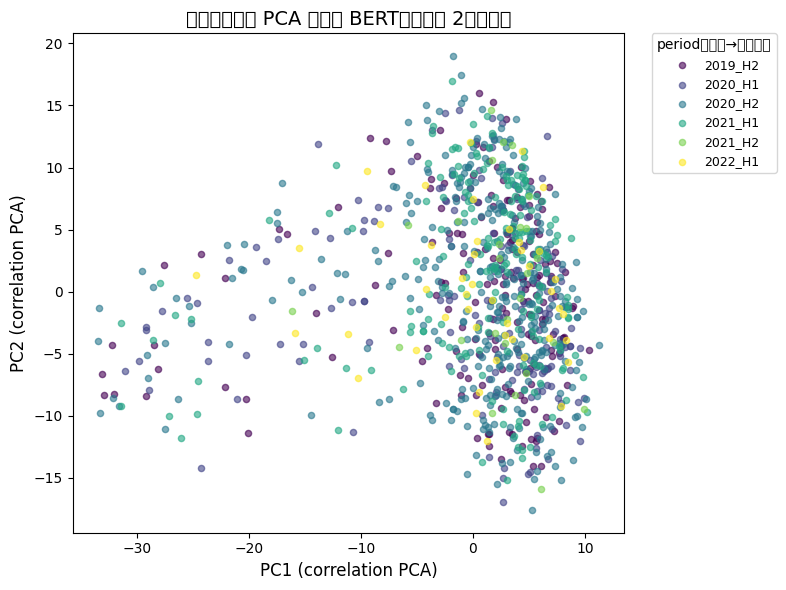

C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:268: UserWarning: Glyph 21322 (\N{CJK UNIFIED IDEOGRAPH-534A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:268: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:268: UserWarning: Glyph 12372 (\N{HIRAGANA LETTER GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:268: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:268: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mzjin\AppData\Local\Temp\ipykernel_15824\276789103.py:268: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-

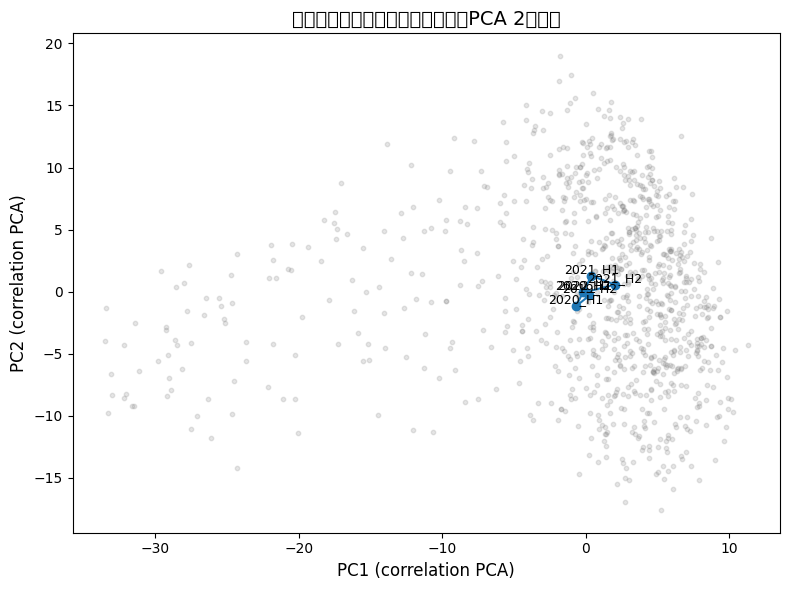

In [15]:
# ===============================================
# BERT埋め込み + 相関係数行列 PCA で
# ツイートの意味空間を可視化する完全スクリプト
#
# - ローカルBERTモデル: C:/hf_models/bert-japanese-v2
# - 入力CSV         : C:/Users/mzjin/OneDrive/デスクトップ/tweet(original).csv
# - 出力           : 相関行列PCAの2次元散布図（半年ごとに色分け + 重心の軌跡）
# ===============================================

import os
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"  # 念のためHFのテレメトリをOFF（なくてもOK）

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# -----------------------------------------------
# 0. 設定
# -----------------------------------------------
INPUT_CSV = r"C:\Users\mzjin\OneDrive\デスクトップ\tweet(original).csv"
MODEL_DIR = r"C:\hf_models\bert-japanese-v2"

# GPU があれば GPU を使う
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


# -----------------------------------------------
# 1. データ読み込み & 前処理
# -----------------------------------------------
def load_and_prepare_data(csv_path: str) -> pd.DataFrame:
    """
    tweet(original).csv を読み込み、
    - datetime列を datetime 型に変換
    - text の欠損を空文字に
    - 半年ごとの period ラベルを追加
    を行った DataFrame を返す。
    """
    # CSV 読み込み（[0列: 日付文字列, 1列: テキスト] 前提）
    df = pd.read_csv(csv_path, header=None, encoding="utf-8")
    df.columns = ["datetime", "text"]

    # "Jun 29,2022" → "Jun 29, 2022" 的なカンマ周りの空白を整形
    df["datetime"] = (
        df["datetime"]
        .astype(str)
        .str.replace(r"\s*,\s*", ",", regex=True)
        .str.strip()
    )

    # 日付文字列を datetime 型に変換（例: "Jun 29,2022"）
    df["datetime"] = pd.to_datetime(
        df["datetime"],
        format="%b %d,%Y",
        errors="coerce",  # 変換できないものは NaT
    )

    print("先頭5行:")
    print(df.head())
    print("NaT 割合:", df["datetime"].isna().mean())

    # 日付が読めない行は除外
    df = df.dropna(subset=["datetime"]).reset_index(drop=True)

    # テキストが欠損なら空文字に
    df["text"] = df["text"].fillna("")

    # 半年ごとの期間ラベルを作る
    def make_halfyear_label(ts):
        year = ts.year
        half = 1 if ts.month <= 6 else 2
        return f"{year}_H{half}"

    df["period"] = df["datetime"].apply(make_halfyear_label)

    print("期間ごとの件数：")
    print(df["period"].value_counts().sort_index())
    print()

    return df


# -----------------------------------------------
# 2. BERT モデルの読み込み（ローカル）
# -----------------------------------------------
def load_bert_model(model_dir: str):
    """
    ローカルディレクトリから日本語 BERT モデルとトークナイザを読み込む。
    """
    print("ローカルモデル読み込み中...")
    tokenizer = AutoTokenizer.from_pretrained(model_dir, local_files_only=True)
    model = AutoModel.from_pretrained(model_dir, local_files_only=True).to(device)
    model.eval()
    print("モデル読み込み完了")
    return tokenizer, model


# -----------------------------------------------
# 3. テキストを BERT ベクトルに変換
# -----------------------------------------------
def encode_texts(texts, tokenizer, model, batch_size=16, max_length=128):
    """
    texts: pandas.Series または list[str]
    戻り値: numpy.ndarray (N, D)
    """
    all_embs = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size].tolist()

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)
            # [CLS] トークンのベクトルを使用
            cls_emb = outputs.last_hidden_state[:, 0, :]  # (B, hidden_size)
            # L2 正規化（ベクトルの長さを1に揃える）
            cls_emb = torch.nn.functional.normalize(cls_emb, p=2, dim=1)

        all_embs.append(cls_emb.cpu().numpy())

        # ざっくり進捗表示
        if (i // batch_size) % 10 == 0:
            print(f"  encoded {i + len(batch_texts)} / {len(texts)}")

    return np.vstack(all_embs)


# -----------------------------------------------
# 4. 相関係数行列 PCA（＝標準化 + PCA）
# -----------------------------------------------
def run_corr_pca(embeddings: np.ndarray, n_components: int = 2):
    """
    embeddings: (N, D) の埋め込みベクトル
    1. Zスコア標準化
    2. PCA (標準化後 → 相関行列ベースのPCAに相当)
    を行い、(N, n_components) の主成分スコアと PCA モデルを返す。
    """
    print("標準化 (Z-score) 実行中...")
    scaler = StandardScaler()
    X_std = scaler.fit_transform(embeddings)

    print("相関係数行列 PCA 実行中...")
    pca = PCA(n_components=n_components, random_state=0)
    X_2d = pca.fit_transform(X_std)
    print("相関PCA 完了。分散説明率:", pca.explained_variance_ratio_)
    return X_2d, pca


# -----------------------------------------------
# 5. period を時間順に並べるユーティリティ
# -----------------------------------------------
def period_to_order(p: str) -> int:
    """
    "2020_H1" -> 2020*2 + (1-1) = 4040
    "2020_H2" -> 2020*2 + (2-1) = 4041
    のように、時間順を一意に表す整数に変換する。
    """
    year_str, half_str = p.split("_H")
    year = int(year_str)
    half = int(half_str)
    return year * 2 + (half - 1)


# -----------------------------------------------
# 6. 散布図の描画（相関PCAの結果）
# -----------------------------------------------
def plot_corr_pca_scatter(df: pd.DataFrame):
    """
    df: 以下の列を持つ DataFrame
        - pc1_corr, pc2_corr: 相関PCAで2次元に圧縮した座標
        - period: 半年ごとのラベル (例: "2020_H1")
    """

    # 時系列順にユニークな period を並べる
    unique_periods = sorted(df["period"].unique(), key=period_to_order)

    # 古い matplotlib でも動くカラーマップ
    cmap = plt.cm.viridis

    # ---- 6-1. ツイート散布図（点を半年ごとに色分け） ----
    plt.figure(figsize=(8, 6))

    denom = max(len(unique_periods) - 1, 1)  # 0除算を避ける

    for idx, period in enumerate(unique_periods):
        mask = df["period"] == period

        # 0〜1の範囲で色をずらす
        color = cmap(idx / denom)

        plt.scatter(
            df.loc[mask, "pc1_corr"],
            df.loc[mask, "pc2_corr"],
            s=20,
            alpha=0.6,
            color=color,
            label=period,
        )

    plt.xlabel("PC1 (correlation PCA)", fontsize=12)
    plt.ylabel("PC2 (correlation PCA)", fontsize=12)
    plt.title("相関係数行列 PCA による BERT埋め込み 2次元表示", fontsize=14)
    plt.legend(
        title="period（古い→新しい）",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

    # ---- 6-2. 半年ごとの「重心」を線で結んで時系列を強調 ----
    centroids = (
        df.groupby("period")[["pc1_corr", "pc2_corr"]]
        .mean()
        .loc[unique_periods]  # 時系列順に並べ替え
        .reset_index()
    )

    plt.figure(figsize=(8, 6))

    # 背景に全ツイートを薄く表示
    plt.scatter(
        df["pc1_corr"], df["pc2_corr"],
        s=10,
        alpha=0.2,
        color="gray",
        label="tweets",
    )

    # 重心を線で結ぶ（時系列の軌跡）
    plt.plot(
        centroids["pc1_corr"],
        centroids["pc2_corr"],
        marker="o",
        linestyle="-",
    )

    # 各重心に period ラベルを表示
    for _, row in centroids.iterrows():
        plt.text(
            row["pc1_corr"],
            row["pc2_corr"],
            row["period"],
            fontsize=9,
            ha="center",
            va="bottom",
        )

    plt.xlabel("PC1 (correlation PCA)", fontsize=12)
    plt.ylabel("PC2 (correlation PCA)", fontsize=12)
    plt.title("半年ごとの意味空間の軌跡（相関PCA 2次元）", fontsize=14)
    plt.tight_layout()
    plt.show()


# -----------------------------------------------
# メイン処理
# -----------------------------------------------
def main():
    # 1. データ読み込み
    df = load_and_prepare_data(INPUT_CSV)

    # 2. BERTモデル読み込み
    tokenizer, model = load_bert_model(MODEL_DIR)

    # 3. テキストを BERT 埋め込みに変換
    print("テキストをエンコード中...")
    embeddings = encode_texts(df["text"], tokenizer, model)
    print("エンコード完了: 形状 =", embeddings.shape)  # (N, D)

    # 4. 相関係数行列 PCA（標準化 + PCA）
    X_corr_2d, pca = run_corr_pca(embeddings, n_components=2)

    # 5. 主成分スコアを df に追加
    df["pc1_corr"] = X_corr_2d[:, 0]
    df["pc2_corr"] = X_corr_2d[:, 1]

    # 6. 散布図を描画（色=半年、重心の軌跡付き）
    plot_corr_pca_scatter(df)


if __name__ == "__main__":
    main()
